In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
# Manual convolution (no np.convolve)
def manual_convolve_same(x, h):
    nx = len(x)
    nh = len(h)
    nfull = nx + nh - 1

    # Full linear convolution using nested loops
    y_full = np.zeros(nfull)
    for i in range(nx):
        for j in range(nh):
            y_full[i + j] += (x[i] * h[j])

    # Convert to 'same' length (center part)
    start = (nh - 1) // 2
    end = start + nx
    return y_full[start:end]

In [3]:
# Parameters
fs = 100
f0 = 10
noise_std = 0.5

# Time axis and noisy signal generation
t = np.arange(0, 1.0, 1 / fs)
clean = np.sin(2 * np.pi * f0 * t)
noise = noise_std * np.random.randn(len(t))
x_noisy = clean + noise

# 6-point difference-equation smoothing filter:
# y[n] = (1/6) * (x[n] + x[n-1] + x[n-2] + x[n-3] + x[n-4] + x[n-5])
h = np.ones(6) / 6
y_filtered = manual_convolve_same(x_noisy, h)

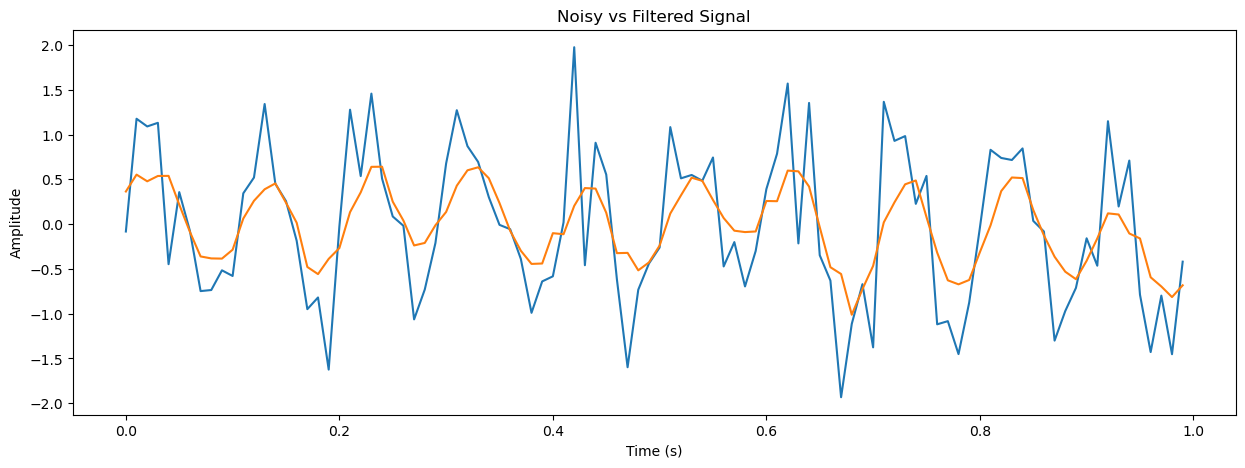

In [4]:
# Plot original noisy and filtered signals
plt.figure(figsize=(15, 5))
plt.plot(t, x_noisy)
plt.plot(t, y_filtered)
plt.title('Noisy vs Filtered Signal')
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.show()